In [35]:
pip install scikit-learn 


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:
import sklearn
print(sklearn.__version__)

1.5.2


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from mpl_toolkits.mplot3d import Axes3D

#Data Exploration 
# Load the dataset (“titanic dataset”) 
heart=pd.read_csv('heartdata.csv') 
heart

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,150,32.66,14.54,Yes,0,30,16,12
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,165,77.11,28.29,No,0,30,0,4
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,163,88.45,33.47,No,4,12,3,16
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,180,93.44,28.73,No,0,30,30,8
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,191,88.45,24.37,Yes,0,8,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5027,Excellent,Within the past 2 years,Yes,No,No,No,No,No,No,Female,18-24,155,49.90,20.78,No,0,12,30,0
5028,Good,5 or more years ago,Yes,No,No,No,No,No,No,Male,30-34,168,90.72,32.28,No,0,30,0,4
5029,Excellent,Within the past year,Yes,No,No,No,No,"Yes, but female told only during pregnancy",No,Female,45-49,165,83.46,30.62,No,8,90,12,4
5030,Very Good,Within the past year,Yes,No,No,No,No,No,No,Female,25-29,165,65.77,24.13,No,12,30,15,8


In [38]:
  heart.head()

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,150,32.66,14.54,Yes,0,30,16,12
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,165,77.11,28.29,No,0,30,0,4
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,163,88.45,33.47,No,4,12,3,16
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,180,93.44,28.73,No,0,30,30,8
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,191,88.45,24.37,Yes,0,8,4,0


In [39]:
heart.tail()

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
5027,Excellent,Within the past 2 years,Yes,No,No,No,No,No,No,Female,18-24,155,49.90,20.78,No,0,12,30,0
5028,Good,5 or more years ago,Yes,No,No,No,No,No,No,Male,30-34,168,90.72,32.28,No,0,30,0,4
5029,Excellent,Within the past year,Yes,No,No,No,No,"Yes, but female told only during pregnancy",No,Female,45-49,165,83.46,30.62,No,8,90,12,4
5030,Very Good,Within the past year,Yes,No,No,No,No,No,No,Female,25-29,165,65.77,24.13,No,12,30,15,8
5031,Very Good,5 or more years ago,Yes,No,No,No,No,Yes,No,Female,60-64,157,81.65,32.92,No,4,30,20,10


In [40]:
# Check basic information about the dataset 
heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5032 entries, 0 to 5031
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   General_Health                5032 non-null   object 
 1   Checkup                       5032 non-null   object 
 2   Exercise                      5032 non-null   object 
 3   Heart_Disease                 5032 non-null   object 
 4   Skin_Cancer                   5032 non-null   object 
 5   Other_Cancer                  5032 non-null   object 
 6   Depression                    5032 non-null   object 
 7   Diabetes                      5032 non-null   object 
 8   Arthritis                     5032 non-null   object 
 9   Sex                           5032 non-null   object 
 10  Age_Category                  5032 non-null   object 
 11  Height_(cm)                   5032 non-null   int64  
 12  Weight_(kg)                   5032 non-null   float64
 13  BMI

In [41]:
# Check basic statistical description 
heart.describe() 

,Height_(cm),Weight_(kg),BMI,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
count,5032.000000,5032.000000,5032.000000,5032.000000,5032.000000,5032.000000,5032.000000
mean,170.538355,84.549549,28.998601,4.197933,26.679849,13.674086,6.406995
std,10.744023,21.621629,6.724578,7.685154,23.394592,14.312284,8.803295
min,122.000000,32.660000,13.310000,0.000000,0.000000,0.000000,0.000000
25%,163.000000,68.040000,24.390000,0.000000,8.000000,4.000000,1.000000
50%,170.000000,81.650000,27.980000,0.000000,24.000000,10.000000,4.000000
75%,178.000000,97.520000,32.280000,4.000000,30.000000,20.000000,8.000000
max,224.000000,235.870000,89.100000,30.000000,120.000000,120.000000,120.000000


In [42]:
# type of the data 
type(heart) 

pandas.core.frame.DataFrame

In [43]:
# dataset columns 
heart.columns 

Index(['General_Health', 'Checkup', 'Exercise', 'Heart_Disease', 'Skin_Cancer',
       'Other_Cancer', 'Depression', 'Diabetes', 'Arthritis', 'Sex',
       'Age_Category', 'Height_(cm)', 'Weight_(kg)', 'BMI', 'Smoking_History',
       'Alcohol_Consumption', 'Fruit_Consumption',
       'Green_Vegetables_Consumption', 'FriedPotato_Consumption'],
      dtype='object')

In [44]:
# number of rows 
len(heart.axes[0]) 

5032

In [45]:
# number of variables 
len(heart.axes[1])

19

In [46]:
# Total count of each column 
heart.count()

General_Health                  5032
Checkup                         5032
Exercise                        5032
Heart_Disease                   5032
Skin_Cancer                     5032
Other_Cancer                    5032
Depression                      5032
Diabetes                        5032
Arthritis                       5032
Sex                             5032
Age_Category                    5032
Height_(cm)                     5032
Weight_(kg)                     5032
BMI                             5032
Smoking_History                 5032
Alcohol_Consumption             5032
Fruit_Consumption               5032
Green_Vegetables_Consumption    5032
FriedPotato_Consumption         5032
dtype: int64

In [47]:
#Preprocessing 
# Check for missing values 
print(heart.isnull().sum()) 

General_Health                  0
Checkup                         0
Exercise                        0
Heart_Disease                   0
Skin_Cancer                     0
Other_Cancer                    0
Depression                      0
Diabetes                        0
Arthritis                       0
Sex                             0
Age_Category                    0
Height_(cm)                     0
Weight_(kg)                     0
BMI                             0
Smoking_History                 0
Alcohol_Consumption             0
Fruit_Consumption               0
Green_Vegetables_Consumption    0
FriedPotato_Consumption         0
dtype: int64


In [48]:
heart.duplicated() . sum() 

np.int64(0)

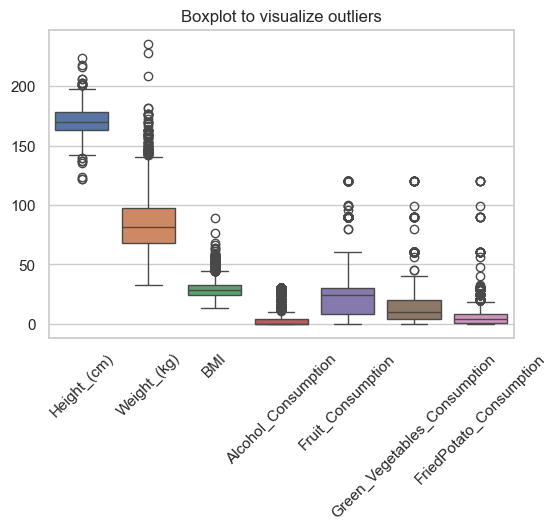

In [49]:
plt.figure(figsize=(6,4))
sns.boxplot(data=heart)
plt.xticks(rotation=45)
plt.title('Boxplot to visualize outliers')
plt.show()

In [50]:
# Create a LabelEncoder object
le = LabelEncoder()
# Apply Label Encoding to categorical columns
heart['Diabetes']=le.fit_transform(heart['Diabetes'])
heart.head()

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,Within the past 2 years,No,No,No,No,No,0,Yes,Female,70-74,150,32.66,14.54,Yes,0,30,16,12
1,Very Good,Within the past year,No,Yes,No,No,No,2,No,Female,70-74,165,77.11,28.29,No,0,30,0,4
2,Very Good,Within the past year,Yes,No,No,No,No,2,No,Female,60-64,163,88.45,33.47,No,4,12,3,16
3,Poor,Within the past year,Yes,Yes,No,No,No,2,No,Male,75-79,180,93.44,28.73,No,0,30,30,8
4,Good,Within the past year,No,No,No,No,No,0,No,Male,80+,191,88.45,24.37,Yes,0,8,4,0


In [51]:
# Create a LabelEncoder object
le = LabelEncoder()
# Apply Label Encoding to categorical columns
heart['Depression']=le.fit_transform(heart['Depression'])
heart.head()

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,Within the past 2 years,No,No,No,No,0,0,Yes,Female,70-74,150,32.66,14.54,Yes,0,30,16,12
1,Very Good,Within the past year,No,Yes,No,No,0,2,No,Female,70-74,165,77.11,28.29,No,0,30,0,4
2,Very Good,Within the past year,Yes,No,No,No,0,2,No,Female,60-64,163,88.45,33.47,No,4,12,3,16
3,Poor,Within the past year,Yes,Yes,No,No,0,2,No,Male,75-79,180,93.44,28.73,No,0,30,30,8
4,Good,Within the past year,No,No,No,No,0,0,No,Male,80+,191,88.45,24.37,Yes,0,8,4,0


In [52]:
# Create a LabelEncoder object
le = LabelEncoder()
# Apply Label Encoding to categorical columns
heart['Smoking_History']=le.fit_transform(heart['Smoking_History'])
heart.head()

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,Within the past 2 years,No,No,No,No,0,0,Yes,Female,70-74,150,32.66,14.54,1,0,30,16,12
1,Very Good,Within the past year,No,Yes,No,No,0,2,No,Female,70-74,165,77.11,28.29,0,0,30,0,4
2,Very Good,Within the past year,Yes,No,No,No,0,2,No,Female,60-64,163,88.45,33.47,0,4,12,3,16
3,Poor,Within the past year,Yes,Yes,No,No,0,2,No,Male,75-79,180,93.44,28.73,0,0,30,30,8
4,Good,Within the past year,No,No,No,No,0,0,No,Male,80+,191,88.45,24.37,1,0,8,4,0


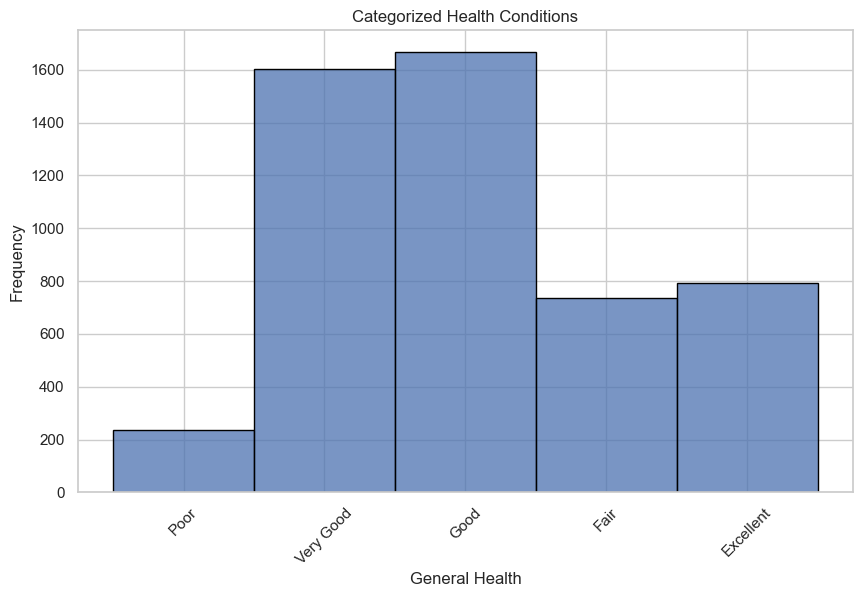

In [53]:
plt.figure(figsize=(10, 6))
sns.histplot(data=heart, x='General_Health', edgecolor='black')
plt.title("Categorized Health Conditions")
plt.xlabel('General Health')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()


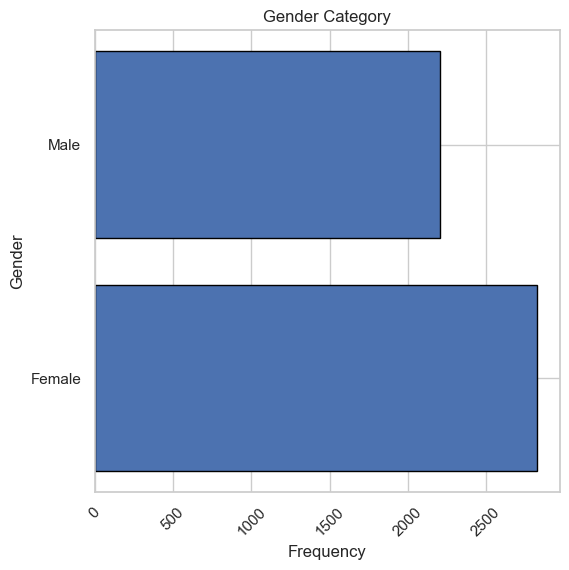

In [54]:
freq_count = heart['Sex'].value_counts()
plt.figure(figsize=(6,6))
plt.barh(freq_count.index, freq_count.values, edgecolor='black')  # Adjust height for thinner bars
plt.title("Gender Category")
plt.xlabel('Frequency')
plt.ylabel('Gender')
plt.xticks(rotation=45)
plt.show()


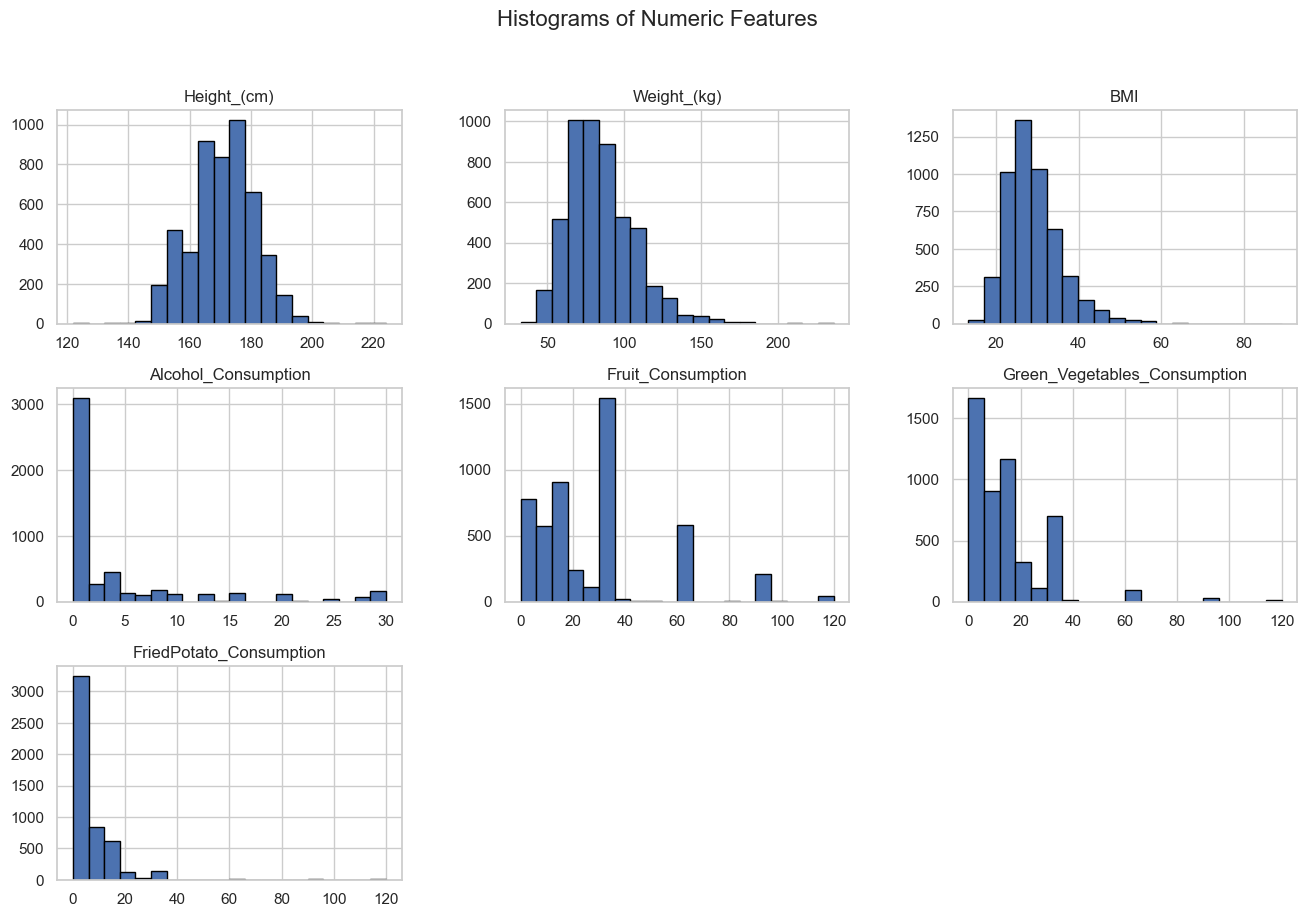

In [55]:

sns.set(style="whitegrid")
numeric_columns = ['Height_(cm)', 'Weight_(kg)', 'BMI', 'Alcohol_Consumption', 'Fruit_Consumption', 
                   'Green_Vegetables_Consumption', 'FriedPotato_Consumption']
heart[numeric_columns].hist(figsize=(16, 10), bins=20, edgecolor='black')
plt.suptitle('Histograms of Numeric Features', fontsize=16)
plt.show()


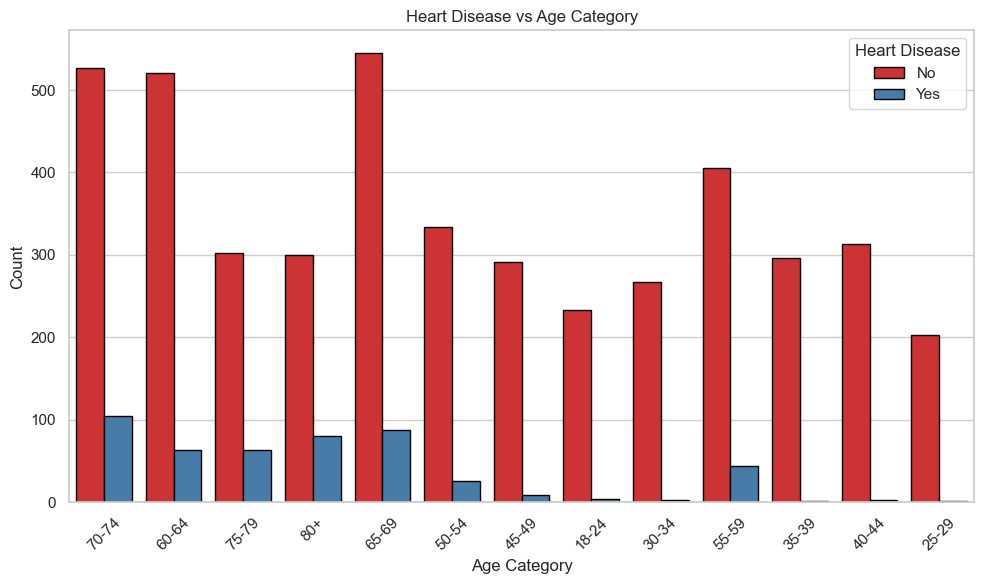

In [56]:
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.countplot(data=heart, x='Age_Category', hue='Heart_Disease', palette='Set1',edgecolor='black')
plt.xticks(rotation=45)
plt.title('Heart Disease vs Age Category')
plt.xlabel('Age Category')
plt.ylabel('Count')
plt.legend(title='Heart Disease')
plt.tight_layout()
plt.show()


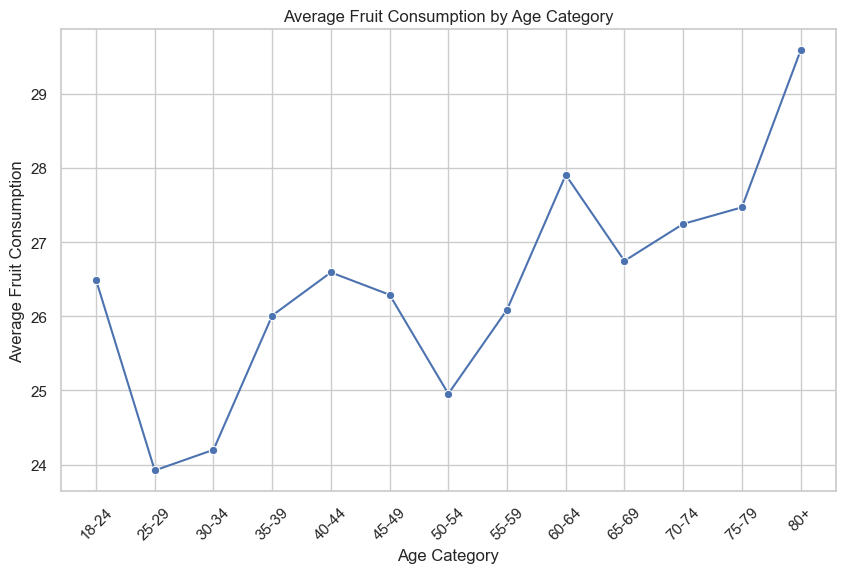

In [57]:
# Line Plot for Age Category vs Average Fruit Consumption
plt.figure(figsize=(10, 6))
age_fruit = heart.groupby('Age_Category')['Fruit_Consumption'].mean().reset_index()
sns.lineplot(data=age_fruit, x='Age_Category', y='Fruit_Consumption', marker='o')
plt.xticks(rotation=45)
plt.title('Average Fruit Consumption by Age Category')
plt.xlabel('Age Category')
plt.ylabel('Average Fruit Consumption')
plt.show()


C:\Users\Dell\AppData\Local\Temp\ipykernel_5012\1436840441.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=heart, y='BMI', x='Age_Category', palette='Set2')


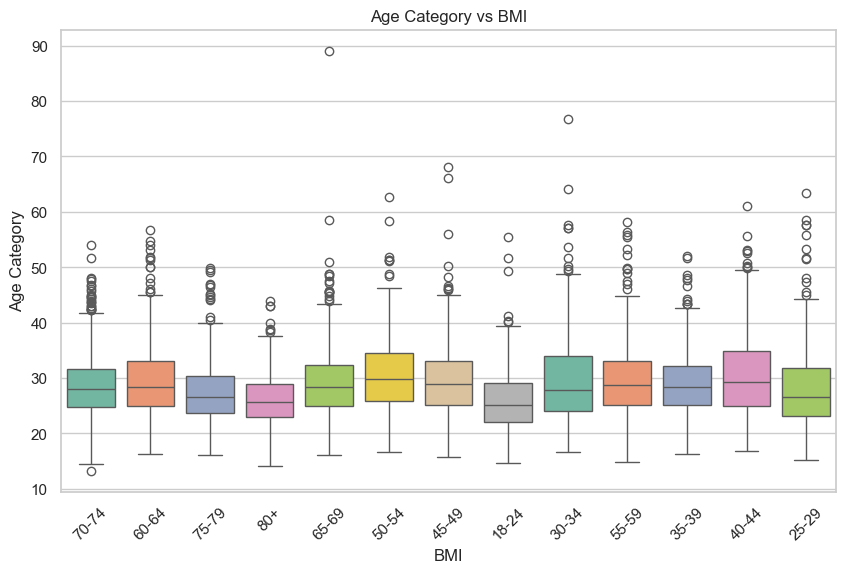

In [58]:
# Box Plot for Age Category vs BMI
plt.figure(figsize=(10, 6))
sns.boxplot(data=heart, y='BMI', x='Age_Category', palette='Set2')
plt.xticks(rotation=45)
plt.title('Age Category vs BMI')
plt.ylabel('Age Category')
plt.xlabel('BMI')

plt.show()


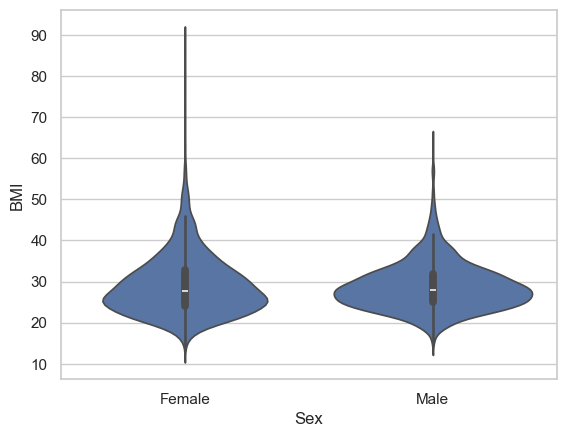

In [59]:
sns.violinplot(data=heart, x='Sex', y='BMI')
plt.show()


[0 2 1 3]
BMI         0
Diabetes    0
dtype: int64


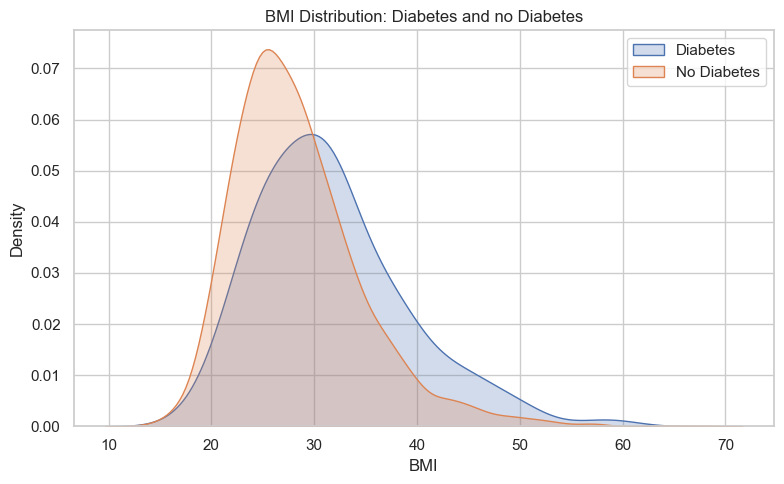

In [60]:

print(heart['Diabetes'].unique())
heart['Diabetes'] = heart['Diabetes'].astype(int) 
print(heart[['BMI', 'Diabetes']].isnull().sum())
plt.figure(figsize=(8, 5))
sns.kdeplot(heart[heart['Diabetes'] == 1]['BMI'], label='Diabetes', fill=True)
sns.kdeplot(heart[heart['Diabetes'] == 0]['BMI'], label='No Diabetes', fill=True)
plt.title('BMI Distribution: Diabetes and no Diabetes')
plt.xlabel('BMI')
plt.legend()
plt.tight_layout()

plt.show()


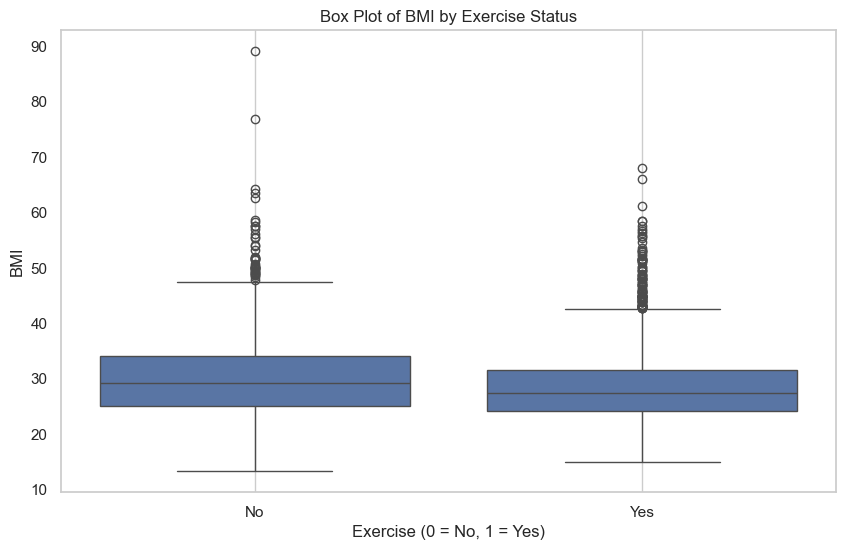

In [61]:
# Box Plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Exercise', y='BMI', data=heart)
plt.title('Box Plot of BMI by Exercise Status')
plt.xlabel('Exercise (0 = No, 1 = Yes)')  # Adjust this based on your actual values
plt.ylabel('BMI')
plt.grid()

# Show the plot
plt.show()


['General_Health', 'Checkup', 'Exercise', 'Heart_Disease', 'Skin_Cancer', 'Other_Cancer', 'Depression', 'Diabetes', 'Arthritis', 'Sex', 'Age_Category', 'Height_(cm)', 'Weight_(kg)', 'BMI', 'Smoking_History', 'Alcohol_Consumption', 'Fruit_Consumption', 'Green_Vegetables_Consumption', 'FriedPotato_Consumption']


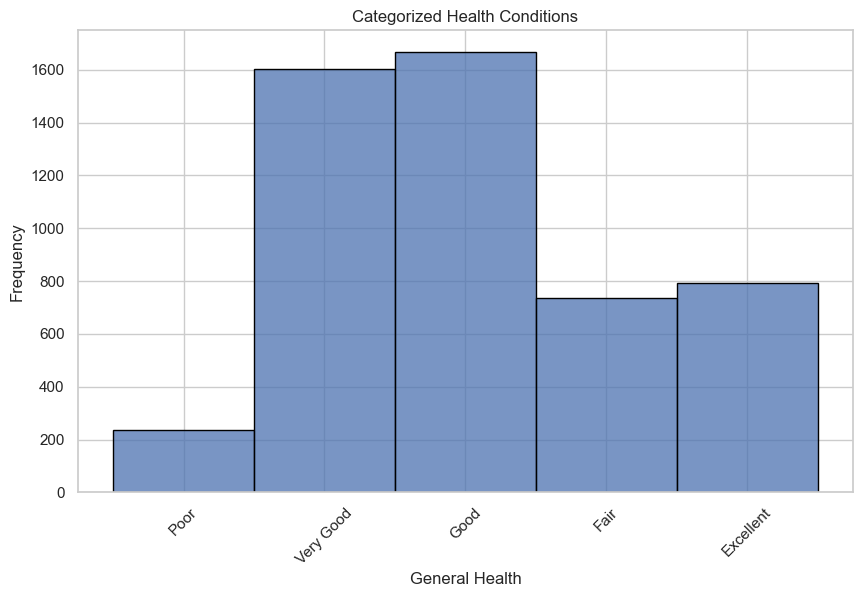

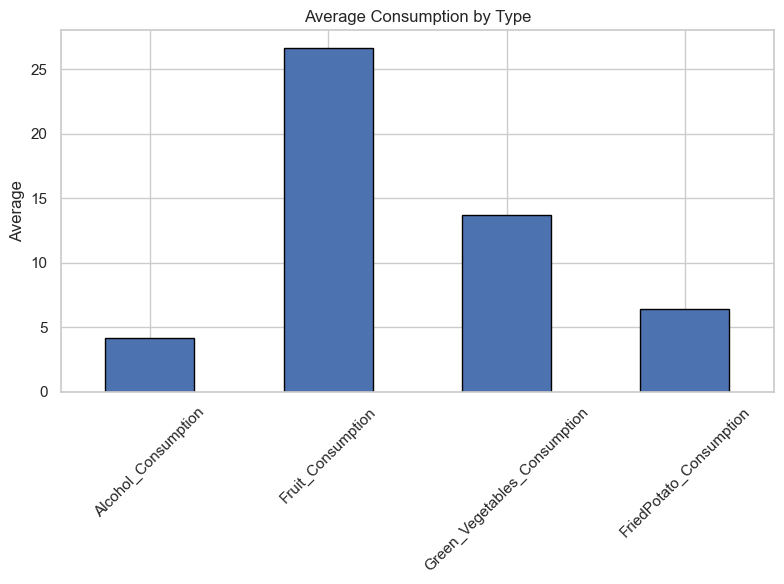

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
heart = pd.read_csv("heartdata.csv")
print(heart.columns.tolist())

# Chart 1: General Health
plt.figure(figsize=(10, 6))
sns.histplot(data=heart, x='General_Health', edgecolor='black')
plt.title("Categorized Health Conditions")
plt.xlabel('General Health')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

# Chart 2: Average Consumption
cols = ['Alcohol_Consumption', 'Fruit_Consumption',
        'Green_Vegetables_Consumption', 'FriedPotato_Consumption']

plt.figure(figsize=(8, 6))
heart[cols].mean().plot(kind='bar', edgecolor='black')
plt.title('Average Consumption by Type')
plt.ylabel('Average')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

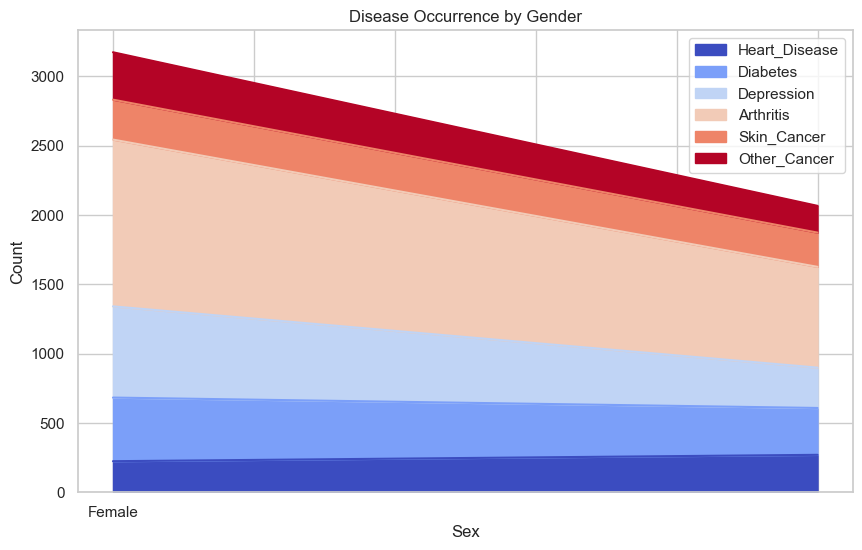

In [63]:

heart['Heart_Disease'] = heart['Heart_Disease'].apply(lambda x: 1 if x == 'Yes' else 0)
heart['Diabetes'] = heart['Diabetes'].apply(lambda x: 1 if x == 'Yes' else 0)
heart['Depression'] = heart['Depression'].apply(lambda x: 1 if x == 'Yes' else 0)
heart['Arthritis'] = heart['Arthritis'].apply(lambda x: 1 if x == 'Yes' else 0)
heart['Skin_Cancer'] = heart['Skin_Cancer'].apply(lambda x: 1 if x == 'Yes' else 0)
heart['Other_Cancer'] = heart['Other_Cancer'].apply(lambda x: 1 if x == 'Yes' else 0)

gender_grouped = heart.groupby('Sex')[['Heart_Disease', 'Diabetes',
'Depression','Arthritis','Skin_Cancer','Other_Cancer']].sum()

gender_grouped.plot(kind='area', stacked=True, figsize=(10, 6), colormap='coolwarm')
plt.title('Disease Occurrence by Gender')
plt.ylabel('Count')
plt.show()


In [64]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import LabelEncoder

# Load the dataset
data = pd.read_csv('heartdata.csv')

# List of categorical columns to encode
categorical_columns=['General_Health', 'Checkup', 'Exercise', 'Heart_Disease', 'Skin_Cancer', 'Other_Cancer', 'Depression', 'Diabetes', 'Arthritis',
 'Sex', 'Age_Category', 'Smoking_History', 'Alcohol_Consumption', 'Fruit_Consumption', 'Green_Vegetables_Consumption', 'FriedPotato_Consumption']

# Initialize LabelEncoder
le = LabelEncoder()

# Apply Label Encoding to each categorical column
for col in categorical_columns:
    data[col] = le.fit_transform(data[col])

# Select Features and Target
X = data[['Height_(cm)', 'Weight_(kg)', 'BMI']]  # Ensure all are numeric
y = data['General_Health']

# Check for any remaining non-numeric columns
non_numeric = X.select_dtypes(include=['object']).columns
if len(non_numeric) > 0:
    print(f"Non-numeric columns: {non_numeric}")
    for col in non_numeric:
        X[col] = le.fit_transform(X[col])
# Split the dataset into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model using R² score (coefficient of determination)
accuracy = r2_score(y_test, y_pred)
print(f'Model accuracy (R² score): {accuracy:.2f}')

# Optionally, compute Mean Squared Error
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse:.2f}')

Model accuracy (R² score): 0.00
Mean Squared Error: 2.02


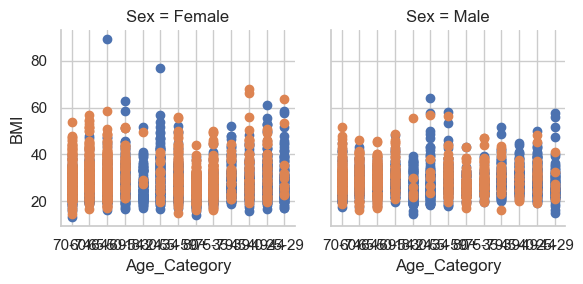

In [65]:
g = sns.FacetGrid(heart, col='Sex', hue='Arthritis')
g.map(plt.scatter, 'Age_Category', 'BMI')
plt.show()


In [66]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler

# Load the dataset
data = pd.read_csv('heartdata.csv')

# Convert categorical variables to numerical format
data_encoded = pd.get_dummies(data, drop_first=True)

# Define features and target variable
X = data_encoded.drop('Heart_Disease_Yes', axis=1)  # Drop target column
y = data_encoded['Heart_Disease_Yes']  # Target variable

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and fit the model with increased max_iter
model = LogisticRegression(max_iter=2000)  # Increase max_iter to allow for convergence
model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test_scaled)
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Accuracy Score: 0.9066534260178749


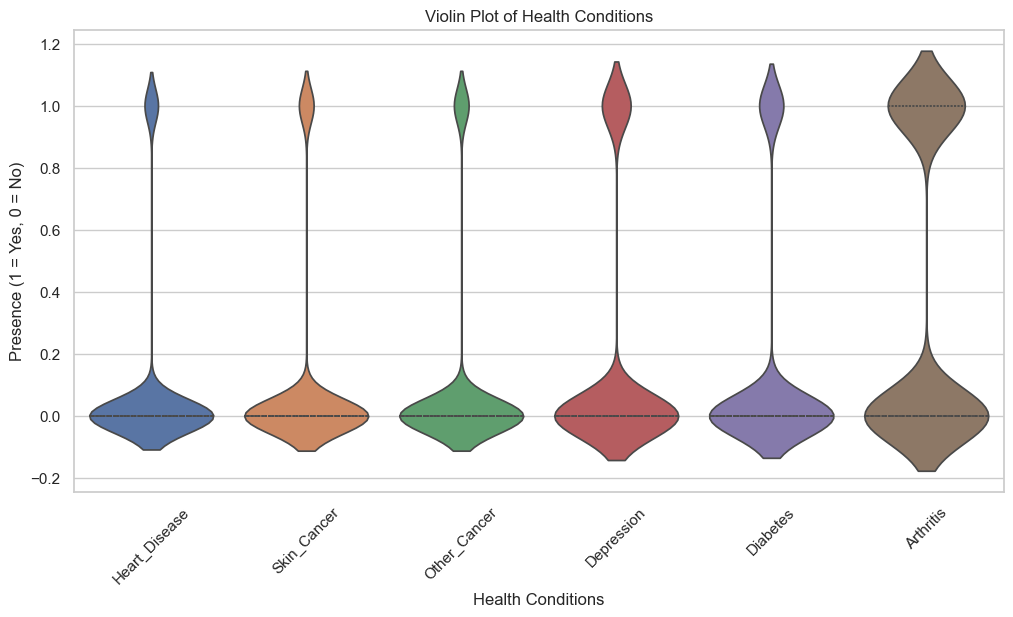

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from mpl_toolkits.mplot3d import Axes3D

#Data Exploration 
# Load the dataset (“titanic dataset”) 
heart=pd.read_csv('heartdata.csv') 
# Step 2: Prepare the data for plotting
# Convert Yes/No to binary values for each health condition
conditions = ['Heart_Disease', 'Skin_Cancer', 'Other_Cancer', 'Depression', 'Diabetes', 'Arthritis']
for condition in conditions:
    heart[condition]=heart[condition].map({'Yes': 1, 'No': 0})

# Step 3: Create a violin plot
plt.figure(figsize=(12, 6))
sns.violinplot(data=heart[conditions], inner='quartile')
plt.title('Violin Plot of Health Conditions')
plt.ylabel('Presence (1 = Yes, 0 = No)')
plt.xlabel('Health Conditions')
plt.xticks(rotation=45)
plt.show()

In [70]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

heart = pd.read_csv('heartdata.csv')

# Features and target
X = heart.drop(columns=['Weight_(kg)', 'BMI', 'Heart_Disease'])
y = heart['Weight_(kg)']

# One-hot encoding for categorical columns
categorical_columns = X.select_dtypes(include=['object']).columns
encoder = OneHotEncoder(drop='first', sparse_output=False)
X_encoded = pd.DataFrame(
    encoder.fit_transform(X[categorical_columns]),
    columns=encoder.get_feature_names_out(categorical_columns),
    index=X.index
)

# Replace original categorical columns with encoded ones
X = pd.concat([X.drop(columns=categorical_columns), X_encoded], axis=1)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("R2 Score:", r2)
print("Mean Absolute Error:", mae)

R2 Score: 0.27779503697395214
Mean Absolute Error: 13.807609442186104
